In [41]:
%matplotlib inline

import sys

sys.path.append('..')

import xarray as xr
import pandas as pd
import numpy as np
from pathlib import Path
from itertools import product
from datetime import datetime
import os
import glob
import matplotlib.pyplot as plt
from open_ocean.utils import convert_climatology_to_ocean_areas
import open_ocean.gridder as gridder
import open_ocean.interpolation as io

In [42]:
data_dir = Path(os.getenv("OODIR"))
coder = xr.coders.CFDatetimeCoder(time_unit="s")

In [43]:
data_file = data_dir / "IQUAM" / "OutputData" / "timeseries_with_uncertainty.csv"
data = pd.read_csv(data_file, header=[0, 1], index_col=0)
time = np.arange(len(data)) / 12. + 1981 + 8 / 12.

ship = data['ship']['Global']
ship_unc = data['ship_unc']['Global']

drifter = data['drifter']['Global']
drifter_unc = data['drifter_unc']['Global']

argo = data['argo']['Global']
argo_unc = data['argo_unc']['Global']

interp = data['interp']['Global']
interp_unc = data['interp_unc']['Global']

In [44]:
ts_dir = data_dir / "ICOADS" / "OutputData"
ts_files = ts_dir.glob('timeseries_with_uncertainty_*.csv')
icoads_data = pd.concat((pd.read_csv(f, header=[0, 1], index_col=0) for f in ts_files), ignore_index=True)

#icoads_data_file = data_dir / "ICOADS" / "OutputData" / "timeseries_with_uncertainty.csv"
#icoads_data = pd.read_csv(icoads_data_file, header=[0, 1], index_col=0)
icoads_time = np.arange(len(icoads_data)) / 12. + 1850.

icship = icoads_data['ship']['Global']
icship_unc = icoads_data['ship_unc']['Global']

icdrifter = icoads_data['drifter']['Global']
icdrifter_unc = icoads_data['drifter_unc']['Global']

icinterp = icoads_data['interp']['Global']
icinterp_unc = icoads_data['interp_unc']['Global']

icinterp2 = icoads_data['interp2']['Global']
icinterp2_unc = icoads_data['interp2_unc']['Global']

icinterp_run = icoads_data['interp_run']['Global']
icinterp_run_unc = icoads_data['interp_run_unc']['Global']

In [45]:
def ma(a, n=12):
    ret = np.cumsum(a, dtype=float)
    ret[n:] = ret[n:] - ret[:-n]
    return ret[n - 1:] / n

(-1.5, 0.3)

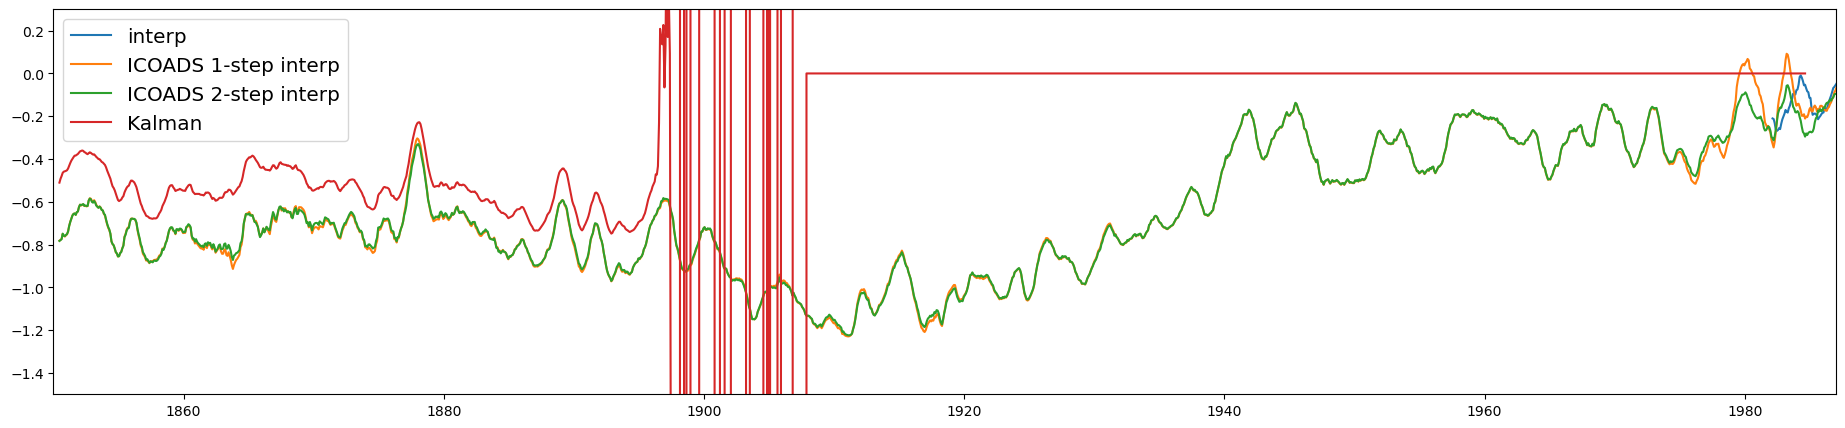

In [46]:
y1=1995
y2=2005
selection = (time >= y1) & (time <=y2)
icselection = (icoads_time >= y1) & (icoads_time <=y2)

plt.figure()
plt.gcf().set_size_inches(23, 5)

# plt.plot(ma(ersst_time), ma(ersst_weighted_mean - np.mean(ersst_weighted_mean[eselection])), label='ERSST')
# plt.plot(ma(h4_time), ma(h4_weighted_mean.values - np.mean(h4_weighted_mean.values[hselection])), label='HadSST4')
plt.plot(ma(time), ma(interp.values - np.mean(interp.values[selection])), label='interp')
plt.plot(ma(icoads_time), ma(icinterp.values - np.mean(icinterp.values[icselection])), label='ICOADS 1-step interp')
plt.plot(ma(icoads_time), ma(icinterp2.values - np.mean(icinterp2.values[icselection])), label='ICOADS 2-step interp')
plt.plot(ma(icoads_time), ma(icinterp_run.values[0:len(icoads_time)]), label='Kalman')
#plt.plot(ma(cci_time), ma(cci_weighted_mean - np.mean(cci_weighted_mean[cselection])), label='CCI')

plt.legend(fontsize='x-large')
plt.xlim(1850, 1987)
plt.ylim(-1.5, 0.3)

(-1.5, 0.3)

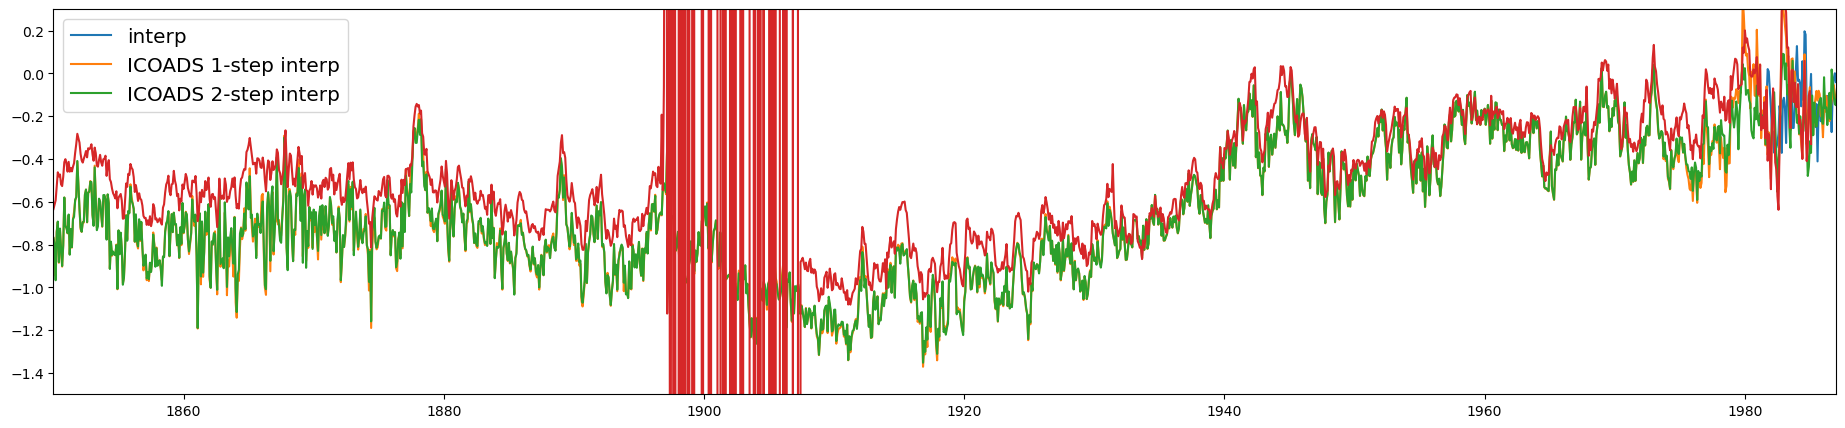

In [47]:
plt.figure()
plt.gcf().set_size_inches(23, 5)

plt.plot(time, interp.values - np.mean(interp.values[selection]), label='interp')
plt.plot(icoads_time, icinterp.values - np.mean(icinterp.values[icselection]), label='ICOADS 1-step interp')
plt.plot(icoads_time, icinterp2.values - np.mean(icinterp2.values[icselection]), label='ICOADS 2-step interp')
plt.plot(icoads_time, icinterp_run.values[0:len(icoads_time)])

plt.legend(fontsize='x-large')
plt.xlim(1850, 1987)
plt.ylim(-1.5, 0.3)

(1850.0, 1997.0)

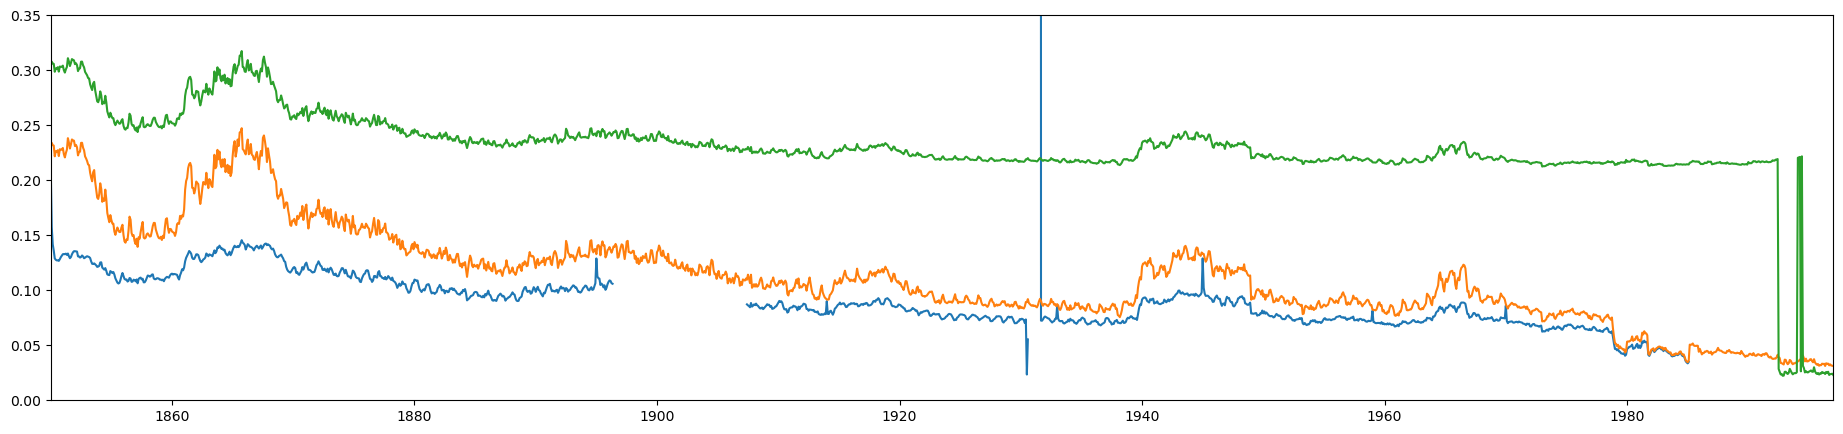

In [48]:
plt.figure()
plt.gcf().set_size_inches(23, 5)

plt.plot(icoads_time, icinterp_run_unc)
plt.plot(icoads_time, icinterp_unc)
plt.plot(icoads_time, icinterp2_unc)

plt.ylim(0, 0.35)
plt.xlim(1850,1997)